In [1]:
##Cell 0
# ============ PRE-FLIGHT (must run first, on a fresh kernel) ============
import os

# Reduce TF log spam (1=INFO, 2=WARNING, 3=ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# Disable OneDNN ops (avoids non-determinism warnings; we're on GPU anyway)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# Better GPU memory allocator (TF 2.10 supports this)
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

print("Environment configured. NOW import TensorFlow.")

Environment configured. NOW import TensorFlow.


In [4]:
## Cell 1
import shutil
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50V2
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout,
                                     BatchNormalization, Input, Lambda)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import mixed_precision
import tensorflow.keras.backend as K

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Verify versions
print(f"TensorFlow : {tf.__version__}    (expect 2.10.x)")
print(f"NumPy      : {np.__version__}    (expect 1.23.5)")
print(f"OpenCV     : {cv2.__version__}")
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"Built with cuDNN : {tf.test.is_built_with_gpu_support()}")

# ============ GPU CONFIGURATION ============
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detected: {len(gpus)}")

USE_MIXED_PRECISION = False  # we will auto-enable below if GPU supports it
USE_XLA = False              # XLA JIT — extra speedup if no compatibility issues

if gpus:
    try:
        # 1) Memory growth — allocate only what we need
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("  Memory growth: ENABLED")

        # 2) Print GPU details
        details = tf.config.experimental.get_device_details(gpus[0])
        gpu_name = details.get('device_name', 'Unknown')
        cc = details.get('compute_capability', (0, 0))
        print(f"  Device           : {gpu_name}")
        print(f"  Compute capability: {cc[0]}.{cc[1]}")

        # 3) Mixed precision — only on GPUs with Tensor Cores (compute capability >= 7.0)
        if cc[0] >= 7:
            mixed_precision.set_global_policy('mixed_float16')
            USE_MIXED_PRECISION = True
            print("  Mixed precision  : ENABLED (mixed_float16 — uses Tensor Cores)")
        else:
            print("  Mixed precision  : SKIPPED (your GPU has no Tensor Cores; FP32 is best)")

        # 4) XLA JIT compilation — graph optimization, often 10-30% faster
        # Note: can be unstable with custom losses. Set USE_XLA=True to try it.
        if USE_XLA:
            tf.config.optimizer.set_jit(True)
            print("  XLA JIT          : ENABLED")

    except RuntimeError as e:
        print(" GPU config error:", e)
else:
    print("  No GPU detected. Re-check CUDA/cuDNN install.")

# 5) Threading config (helps CPU-side data prep)
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(2)

# 6) Quick GPU benchmark
if gpus:
    with tf.device('/GPU:0'):
        a = tf.random.normal([2048, 2048])
        # Warmup
        for _ in range(3):
            _ = tf.matmul(a, a)
        t = time.time()
        for _ in range(20):
            b = tf.matmul(a, a)
        _ = b.numpy()
        print(f"  GPU matmul (2048x2048) : {(time.time()-t)*50:.2f} ms/op")
print("Setup OK")

TensorFlow : 2.10.0    (expect 2.10.x)
NumPy      : 1.23.5    (expect 1.23.5)
OpenCV     : 4.8.1
Built with CUDA  : True
Built with cuDNN : True
GPUs detected: 1
  Memory growth: ENABLED
  Device           : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Compute capability: 8.6
  Mixed precision  : ENABLED (mixed_float16 — uses Tensor Cores)
  GPU matmul (2048x2048) : 14.48 ms/op
Setup OK


In [6]:
## Cell 2
## Configure Paths & Hyperparameters

ORIGINAL_2018 = r"kaggle_dataset_2018"
EXPERT_I_2020 = r"kaggle_dataset2_2020\MedicalExpert-I"
EXPERT_II_2020 = r"kaggle_dataset2_2020\MedicalExpert-II"

# Where intermediate datasets will be created
TERNARY_DIR = r"ternary_dataset"
EXTRA_TEST_DIR = r"ternary_extra_test_7fixes"
# ===========================================

IMG_SIZE = 320
BATCH_SIZE = 32          # reduce to 8 if you get OOM errors
NUM_CLASSES = 3
CLASS_NAMES = ['Healthy', 'Moderate', 'Severe']

# Verify paths
for p in [ORIGINAL_2018, EXPERT_I_2020, EXPERT_II_2020]:
    assert os.path.isdir(p), f"NOT FOUND: {p}"
    print(f"OK  {p}")
    print(f"BATCH_SIZE = {BATCH_SIZE} (reduce to 16 if you see OOM error)")

OK  kaggle_dataset_2018
BATCH_SIZE = 32 (reduce to 16 if you see OOM error)
OK  kaggle_dataset2_2020\MedicalExpert-I
BATCH_SIZE = 32 (reduce to 16 if you see OOM error)
OK  kaggle_dataset2_2020\MedicalExpert-II
BATCH_SIZE = 32 (reduce to 16 if you see OOM error)


In [7]:
## Cell 3
# Fix 1: Smarter ternary mapping (KL 0+1 -> Healthy, 2 -> Moderate, 3+4 -> Severe)
GRADE_MAP_2018 = {
    '0': 'Healthy', '1': 'Healthy',
    '2': 'Moderate',
    '3': 'Severe',  '4': 'Severe',
}
GRADE_MAP_2020 = {
    '0Normal':   'Healthy', '1Doubtful': 'Healthy',
    '2Mild':     'Moderate',
    '3Moderate': 'Severe',  '4Severe':   'Severe',
}

def remove_readonly(func, path, excinfo):
    """Fixes Windows PermissionError by forcing write access on cleanup."""
    os.chmod(path, stat.S_IWRITE)
    func(path)
    
if os.path.exists(TERNARY_DIR):
    print(f"Cleaning existing directory: {TERNARY_DIR}...")
    shutil.rmtree(TERNARY_DIR,onerror=remove_readonly)

# 1) Convert 2018 dataset (preserves train/val/test split)
print("Building from 2018 dataset...")
for split in ['train', 'val', 'test']:
    src_split = os.path.join(ORIGINAL_2018, split)
    
    if not os.path.exists(src_split): continue
    
    for grade in os.listdir(src_split):
        new_class = GRADE_MAP_2018.get(grade)
        if new_class is None: continue
        src_dir = os.path.join(src_split, grade)
        dst_dir = os.path.join(TERNARY_DIR, split, new_class)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            unique_name = f"2018_g{grade}_{f}"
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, unique_name))

# 2) Fix 5: Add MedicalExpert-II (2020) into TRAINING set only
print("Adding MedicalExpert-II 2020 into training set...")
if os.path.exists(EXPERT_II_2020):
    for src_folder, new_class in GRADE_MAP_2020.items():
        src_dir = os.path.join(EXPERT_II_2020, src_folder)
        if not os.path.exists(src_dir): continue
            
        dst_dir = os.path.join(TERNARY_DIR, 'train', new_class)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            unique_name = f"2020_{src_folder}_{f}"
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, unique_name))
else:
    print(f"Warning: 2020 dataset directory not found at {EXPERT_II_2020}")
           

print("Final class counts:")
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(TERNARY_DIR, split)
    print(f"{split}:")
    if not os.path.exists(split_dir):
        print("  (Empty directory)")
        continue
    for cls in sorted(os.listdir(os.path.join(TERNARY_DIR, split))):
        cls_dir = os.path.join(split_dir, cls)
        if os.path.isdir(cls_dir):
            n = len(os.listdir(cls_dir))
            print(f"  {cls:10s}: {n}")


Cleaning existing directory: ternary_dataset...
Building from 2018 dataset...
Adding MedicalExpert-II 2020 into training set...
Final class counts:
train:
  Healthy   : 4323
  Moderate  : 1748
  Severe    : 1357
val:
  Healthy   : 481
  Moderate  : 212
  Severe    : 133
test:
  Healthy   : 935
  Moderate  : 447
  Severe    : 274


In [8]:
## Cell 4
def remove_readonly(func, path, excinfo):
    """Fixes Windows PermissionError by forcing write access and handling locks."""
    try:
        os.chmod(path, stat.S_IWRITE)
        func(path)
    except PermissionError:
        time.sleep(0.1)
        try:
            os.chmod(path, stat.S_IWRITE)
            func(path)
        except Exception:
            print(f"Warning: Could not delete locked path: {path}. Try restarting your Jupyter kernel.")
if os.path.exists(EXTRA_TEST_DIR):
    print(f"Cleaning existing directory: {EXTRA_TEST_DIR}...")
    shutil.rmtree(EXTRA_TEST_DIR, onerror=remove_readonly)

print("Building Extra Test Set from MedicalExpert-I 2020...")
if os.path.exists(EXPERT_I_2020):
    for src_folder, new_class in GRADE_MAP_2020.items():
        src_dir = os.path.join(EXPERT_I_2020, src_folder)
        if not os.path.exists(src_dir): continue
        dst_dir = os.path.join(EXTRA_TEST_DIR, new_class)
        os.makedirs(dst_dir, exist_ok=True)
        for f in os.listdir(src_dir):
            unique_name = f"e1_{src_folder}_{f}"
            shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, unique_name))
else:
    print(f"Error: 2020 dataset directory not found at {EXPERT_I_2020}")
    
print("Extra test set (2020 MedicalExpert-I):")
if os.path.exists(EXTRA_TEST_DIR):
    for cls in sorted(os.listdir(EXTRA_TEST_DIR)):
         cls_dir = os.path.join(EXTRA_TEST_DIR, cls)
         if os.path.isdir(cls_dir):
                n = len(os.listdir(cls_dir))
                print(f"  {cls:10s}: {n}")
else:
    print("  (Directory is empty or does not exist)")


Cleaning existing directory: ternary_extra_test_7fixes...
Building Extra Test Set from MedicalExpert-I 2020...
Extra test set (2020 MedicalExpert-I):
  Healthy   : 991
  Moderate  : 232
  Severe    : 427


In [9]:
## Cell 5
def clahe_preprocess(img):
    """Fix 2: CLAHE contrast enhancement."""
    img = img.astype(np.uint8)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB).astype('float32')

train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=10,
    fill_mode='reflect',
)
eval_datagen = ImageDataGenerator(preprocessing_function=clahe_preprocess)

train_gen = train_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)
val_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
test_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
extra_gen = eval_datagen.flow_from_directory(
    EXTRA_TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print("Class indices:", train_gen.class_indices)

# ========== tf.data wrapper for prefetching (key optimization) ==========
AUTOTUNE = tf.data.AUTOTUNE

def to_tf_dataset(keras_gen, training=False):
    """Wrap a Keras Sequence/Generator with tf.data for async prefetching."""
    output_sig = (
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(lambda: keras_gen, output_signature=output_sig)
    if training:
        ds = ds.repeat()
    return ds.prefetch(AUTOTUNE)

# Build datasets
val_ds   = to_tf_dataset(val_gen,   training=False)
test_ds  = to_tf_dataset(test_gen,  training=False)
extra_ds = to_tf_dataset(extra_gen, training=False)

# Calculate steps for repeating datasets
STEPS_TRAIN = len(train_gen)
STEPS_VAL   = len(val_gen)
STEPS_TEST  = len(test_gen)
STEPS_EXTRA = len(extra_gen)
print(f"Steps per epoch — train: {STEPS_TRAIN}, val: {STEPS_VAL}, test: {STEPS_TEST}")

Found 7428 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Class indices: {'Healthy': 0, 'Moderate': 1, 'Severe': 2}
Steps per epoch — train: 233, val: 26, test: 52


In [10]:
## Cell 6
train_datagen = ImageDataGenerator(
    preprocessing_function=clahe_preprocess,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=10,
    fill_mode='reflect',
)
eval_datagen = ImageDataGenerator(preprocessing_function=clahe_preprocess)

train_gen = train_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)
val_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
test_gen = eval_datagen.flow_from_directory(
    os.path.join(TERNARY_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
extra_gen = eval_datagen.flow_from_directory(
    EXTRA_TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print("Class indices:", train_gen.class_indices)

Found 7428 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Class indices: {'Healthy': 0, 'Moderate': 1, 'Severe': 2}


In [11]:
## Cell 7
class MixupGenerator(tf.keras.utils.Sequence):
    """Fix 4: Mixup augmentation."""
    def __init__(self, base_gen, alpha=0.2):
        self.base_gen = base_gen
        self.alpha = alpha
    def __len__(self):
        return len(self.base_gen)
    def __getitem__(self, idx):
        X1, y1 = self.base_gen[idx]
        idx2 = (idx + 1) % len(self.base_gen)
        X2, y2 = self.base_gen[idx2]
        n = min(len(X1), len(X2))
        X1, y1, X2, y2 = X1[:n], y1[:n], X2[:n], y2[:n]
        lam = np.random.beta(self.alpha, self.alpha)
        return (lam * X1 + (1 - lam) * X2,
                lam * y1 + (1 - lam) * y2)
    def on_epoch_end(self):
        self.base_gen.on_epoch_end()

train_gen_mixup = MixupGenerator(train_gen, alpha=0.2)
train_ds = to_tf_dataset(train_gen_mixup, training=True)
print("Mixup + tf.data pipeline ready")

Mixup + tf.data pipeline ready


In [36]:
## Cell 8
# Compute balanced class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

# Convert to a plain Python list of floats (NOT a dict, NOT numpy)
CLASS_WEIGHTS_LIST = [float(w) for w in class_weights_arr]
print("Class weights:", CLASS_WEIGHTS_LIST)
print("Types:", [type(w).__name__ for w in CLASS_WEIGHTS_LIST])

class WeightedFocalLoss(tf.keras.losses.Loss):
    """Focal loss with class weights baked in. Mixed-precision safe."""

    def __init__(self, gamma=2.0, alpha=0.25, class_weights=None,
                 name="weighted_focal_loss"):
        super().__init__(name=name)
        self.gamma = float(gamma)
        self.alpha = float(alpha)
        # Store as a plain Python list — JSON-safe
        self.class_weights_list = (
            [float(w) for w in class_weights] if class_weights is not None else None
        )
        # Materialize tensor lazily inside call() to avoid get_config issues
        self._weights_tensor = (
            tf.constant(self.class_weights_list, dtype=tf.float32)
            if self.class_weights_list is not None else None
        )

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = self.alpha * tf.pow(1.0 - y_pred, self.gamma)
        loss = focal_weight * cross_entropy             # shape: (batch, num_classes)

        # Apply per-class weights
        if self._weights_tensor is not None:
            # Per-sample weight = sum over classes of (one_hot * class_weight)
            sample_w = tf.reduce_sum(y_true * self._weights_tensor, axis=-1, keepdims=True)
            loss = loss * sample_w

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    def get_config(self):
        return {
            "gamma": self.gamma,
            "alpha": self.alpha,
            "class_weights": self.class_weights_list,
            "name": self.name,
        }


Class weights: [0.5727504048114735, 1.4164759725400458, 1.8246131171702284]
Types: ['float', 'float', 'float']


In [47]:
## Cell 9
def get_preprocess_fn(model_name):
    if model_name == 'efficientnet':
        from tensorflow.keras.applications.efficientnet import preprocess_input
    elif model_name == 'densenet':
        from tensorflow.keras.applications.densenet import preprocess_input
    elif model_name == 'resnet':
        from tensorflow.keras.applications.resnet_v2 import preprocess_input
    return preprocess_input

def build_model(model_name='efficientnet'):
    preprocess_fn = get_preprocess_fn(model_name)
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = Lambda(preprocess_fn)(inputs)
    if model_name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'resnet':
        base = ResNet50V2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False

    h = base.output
    h = GlobalAveragePooling2D()(h)
    h = BatchNormalization()(h)
    h = Dense(256, activation='relu')(h); h = Dropout(0.5)(h)
    h = Dense(128, activation='relu')(h); h = Dropout(0.3)(h)
    out = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(h)  # mixed-precision safe
    return Model(inputs, out), base

def make_callbacks(weights_save_path, patience):
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
        ModelCheckpoint(
            weights_save_path,
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True,    # <-- key fix: only save weights, not full model
            verbose=1,
        ),
    ]

def train_full(model_name, save_path,
               epochs_phase1=15, epochs_phase2=20, unfreeze_last=60):
    print(f"{'='*50}Training {model_name.upper()}{'='*50}")
    model, base = build_model(model_name)

    # Make sure save_path uses .h5 (not .keras) for TF 2.10 compatibility
    if not save_path.endswith('.h5'):
        save_path = save_path.rsplit('.', 1)[0] + '.h5'
        print(f"Save path normalized to: {save_path}")

    # ---------- Phase 1: head only ----------
    model.compile(
        optimizer=Adam(1e-3),
        loss=WeightedFocalLoss(class_weights=CLASS_WEIGHTS_LIST),
        metrics=['accuracy'],
    )
    hist1 = model.fit(
        train_ds,
        steps_per_epoch=STEPS_TRAIN,
        validation_data=val_ds,
        validation_steps=STEPS_VAL,
        epochs=epochs_phase1,
        callbacks=make_callbacks(save_path, patience=6),
        verbose=1,
        # NOTE: no class_weight= here. Class weighting is in the loss.
    )

    # ---------- Phase 2: fine-tune ----------
    base.trainable = True
    for layer in base.layers[:-unfreeze_last]:
        layer.trainable = False
    model.compile(
        optimizer=Adam(1e-5),
        loss=WeightedFocalLoss(class_weights=CLASS_WEIGHTS_LIST),
        metrics=['accuracy'],
    )
    hist2 = model.fit(
        train_ds,
        steps_per_epoch=STEPS_TRAIN,
        validation_data=val_ds,
        validation_steps=STEPS_VAL,
        epochs=epochs_phase2,
        callbacks=make_callbacks(save_path, patience=8),
        verbose=1,
    )

    # Save the FULL final model in .h5 format for later loading
    final_weights_path = save_path.replace('.h5', '_final.h5')
    model.save_weights(final_weights_path)
    print(f"Final weights saved -> {final_weights_path}")
    print(f" Best-checkpoint weights also at ->{save_path}")
    return model, hist1, hist2

In [39]:
## Cell 10 Train Model 1 efficient net

model_eff, hist1_eff, hist2_eff = train_full(
    'efficientnet', 'model_efficientnet.h5',
    epochs_phase1=15, epochs_phase2=20)

==================================================Training EFFICIENTNET==================================================
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.1811 - accuracy: 0.4577
Epoch 1: val_accuracy improved from -inf to 0.49031, saving model to model_efficientnet.h5
233/233 [==============================] - 403s 2s/step - loss: 0.1811 - accuracy: 0.4577 - val_loss: 0.1150 - val_accuracy: 0.4903 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.1159 - accuracy: 0.4997
Epoch 2: val_accuracy improved from 0.49031 to 0.64528, saving model to model_efficientnet.h5
233/233 [==============================] - 381s 2s/step - loss: 0.1159 - accuracy: 0.4997 - val_loss: 0.1072 - val_accuracy: 0.6453 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.1076 - accuracy: 0.5570
Epoch 3: val_accuracy improved from 0.64528 to 0.65738, saving model to model_efficientnet.h5
233/233 [============

TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

In [42]:
# Cell 10.1 — Recover the trained model from the saved checkpoint

import os

WEIGHTS_PATH = 'model_efficientnet.h5'  # saved during training by ModelCheckpoint

# Sanity check that the file exists
assert os.path.exists(WEIGHTS_PATH), f"File not found: {WEIGHTS_PATH}"
print(f"Found checkpoint: {WEIGHTS_PATH} ({os.path.getsize(WEIGHTS_PATH)/1e6:.2f} MB)")

# 1) Rebuild the same architecture
model_eff, base_eff = build_model('efficientnet')

# 2) Set base trainable like Phase 2 (so the architecture matches the saved weights exactly)
base_eff.trainable = True
for layer in base_eff.layers[:-60]:
    layer.trainable = False

# 3) Load the best weights from training
model_eff.load_weights(WEIGHTS_PATH)

# 4) Compile so we can evaluate / predict
model_eff.compile(
    optimizer=Adam(1e-5),
    loss=WeightedFocalLoss(class_weights=CLASS_WEIGHTS_LIST),
    metrics=['accuracy'],
)

# 5) Now save a clean copy as final weights
model_eff.save_weights('model_efficientnet_final_weights.h5')
print("model_eff is now restored.")
print("Final weights saved to model_efficientnet_final_weights.h5")

# 6) Quick sanity check — evaluate on validation set
val_loss, val_acc = model_eff.evaluate(val_ds, steps=STEPS_VAL, verbose=1)
print(f"Validation accuracy: {val_acc*100:.2f}%  (should be ~73.85%)")


Found checkpoint: model_efficientnet.h5 (18.20 MB)
model_eff is now restored.
Final weights saved to model_efficientnet_final_weights.h5
26/26 [==============================] - 9s 168ms/step - loss: 0.0750 - accuracy: 0.7385
Validation accuracy: 73.85%  (should be ~73.85%)


In [44]:
## Cell 11 Train Model 2 Densenet121 
model_dense, hist1_dense, hist2_dense = train_full(
    'densenet', 'model_densenet.keras',
    epochs_phase1=15, epochs_phase2=20)

==================================================Training DENSENET==================================================
29084464/29084464 [==============================] - 11s 0us/step
Save path normalized to: model_densenet.h5
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.1400 - accuracy: 0.4685
Epoch 1: val_accuracy improved from -inf to 0.62470, saving model to model_densenet.h5
233/233 [==============================] - 276s 1s/step - loss: 0.1400 - accuracy: 0.4685 - val_loss: 0.1137 - val_accuracy: 0.6247 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.1110 - accuracy: 0.5332
Epoch 2: val_accuracy improved from 0.62470 to 0.63923, saving model to model_densenet.h5
233/233 [==============================] - 264s 1s/step - loss: 0.1110 - accuracy: 0.5332 - val_loss: 0.1062 - val_accuracy: 0.6392 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.1042 - accuracy: 0.5592
Epoch 3: val_accur

NameError: name 'printf' is not defined

In [46]:
# Cell 11.1 — Recover trained DenseNet model

import os

DENSE_WEIGHTS_PATH = 'model_densenet.h5'   # best weights from ModelCheckpoint

assert os.path.exists(DENSE_WEIGHTS_PATH), f"File not found: {DENSE_WEIGHTS_PATH}"
print(f"Found checkpoint: {DENSE_WEIGHTS_PATH} ({os.path.getsize(DENSE_WEIGHTS_PATH)/1e6:.2f} MB)")

# 1) Rebuild architecture
model_dense, base_dense = build_model('densenet')

# 2) Match Phase 2 trainable state (last 60 layers unfrozen)
base_dense.trainable = True
for layer in base_dense.layers[:-60]:
    layer.trainable = False

# 3) Load best weights from training
model_dense.load_weights(DENSE_WEIGHTS_PATH)

# 4) Compile (needed for evaluate)
model_dense.compile(
    optimizer=Adam(1e-5),
    loss=WeightedFocalLoss(class_weights=CLASS_WEIGHTS_LIST),
    metrics=['accuracy'],
)

# 5) Sanity check on validation set
val_loss, val_acc = model_dense.evaluate(val_ds, steps=STEPS_VAL, verbose=1)
print(f"DenseNet validation accuracy: {val_acc*100:.2f}% ")

Found checkpoint: model_densenet.h5 (30.33 MB)
26/26 [==============================] - 9s 170ms/step - loss: 0.0807 - accuracy: 0.7107
DenseNet validation accuracy: 71.07% 


In [48]:
## Cell 12 Train Model 3 Resnet50

model_resnet, hist1_resnet, hist2_resnet = train_full(
    'resnet', 'model_resnet.keras',
    epochs_phase1=15, epochs_phase2=20)

==================================================Training RESNET==================================================
94668760/94668760 [==============================] - 12s 0us/step
Save path normalized to: model_resnet.h5
Epoch 1/15
233/233 [==============================] - ETA: 0s - loss: 0.1670 - accuracy: 0.4512
Epoch 1: val_accuracy improved from -inf to 0.56780, saving model to model_resnet.h5
233/233 [==============================] - 396s 2s/step - loss: 0.1670 - accuracy: 0.4512 - val_loss: 0.1104 - val_accuracy: 0.5678 - lr: 0.0010
Epoch 2/15
233/233 [==============================] - ETA: 0s - loss: 0.1137 - accuracy: 0.5227
Epoch 2: val_accuracy improved from 0.56780 to 0.64407, saving model to model_resnet.h5
233/233 [==============================] - 373s 2s/step - loss: 0.1137 - accuracy: 0.5227 - val_loss: 0.1054 - val_accuracy: 0.6441 - lr: 0.0010
Epoch 3/15
233/233 [==============================] - ETA: 0s - loss: 0.1075 - accuracy: 0.5622
Epoch 3: val_accuracy impr

## Ensemble 3 models

In [50]:
## Cell 12.1
# Cell A — Recover trained ResNet model
import os

RESNET_WEIGHTS_PATH = 'model_resnet.h5'
assert os.path.exists(RESNET_WEIGHTS_PATH), f"Not found: {RESNET_WEIGHTS_PATH}"
print(f"Found: {RESNET_WEIGHTS_PATH} ({os.path.getsize(RESNET_WEIGHTS_PATH)/1e6:.2f} MB)")

model_resnet, base_resnet = build_model('resnet')
base_resnet.trainable = True
for layer in base_resnet.layers[:-60]:
    layer.trainable = False
model_resnet.load_weights(RESNET_WEIGHTS_PATH)
model_resnet.compile(
    optimizer=Adam(1e-5),
    loss=WeightedFocalLoss(class_weights=CLASS_WEIGHTS_LIST),
    metrics=['accuracy'],
)

val_loss, val_acc = model_resnet.evaluate(val_ds, steps=STEPS_VAL, verbose=1)
print(f"ResNet validation accuracy: {val_acc*100:.2f}%  (should be ~72.52%)")


Found: model_resnet.h5 (96.96 MB)
26/26 [==============================] - 8s 201ms/step - loss: 0.0682 - accuracy: 0.7252
ResNet validation accuracy: 72.52%  (should be ~72.52%)


In [52]:
# Cell B — Confirm all models exist
print("Models in memory:")
print(f"  model_eff    : {model_eff is not None}")
print(f"  model_dense  : {model_dense is not None}")
print(f"  model_resnet : {model_resnet is not None}")
print("All 3 models ready for ensemble.")

Models in memory:
  model_eff    : True
  model_dense  : True
  model_resnet : True
All 3 models ready for ensemble.


In [53]:
# Cell C — Test-Time Augmentation function
def predict_with_tta(model, source_dir, n_aug=5):
    """Predict with test-time augmentation (multiple augmented passes averaged)."""
    base_gen = eval_datagen.flow_from_directory(
        source_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    n = base_gen.samples
    probs = np.zeros((n, NUM_CLASSES))

    # Original pass
    base_gen.reset()
    probs += model.predict(base_gen, verbose=0)

    # Augmented passes
    tta_aug = ImageDataGenerator(
        preprocessing_function=clahe_preprocess,
        rotation_range=10,
        horizontal_flip=True,
        zoom_range=0.05,
        width_shift_range=0.05,
        height_shift_range=0.05,
    )
    for i in range(n_aug):
        gen_aug = tta_aug.flow_from_directory(
            source_dir, target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE, class_mode='categorical',
            shuffle=False, seed=42 + i)
        probs += model.predict(gen_aug, verbose=0)

    probs /= (n_aug + 1)
    return probs, base_gen.classes

print("TTA function defined.")

TTA function defined.


In [54]:
# Cell D — Evaluate each model individually (plain + TTA)
test_dir = os.path.join(TERNARY_DIR, 'test')

print("=" * 60)
print("INDIVIDUAL MODEL RESULTS (TEST SET)")
print("=" * 60)

# --- EfficientNet ---
print("--- EfficientNet B0 ---")
eff_probs, y_test = predict_with_tta(model_eff, test_dir, n_aug=5)
eff_pred = np.argmax(eff_probs, axis=1)
eff_acc = np.mean(eff_pred == y_test) * 100
print(f"  EfficientNet + TTA: {eff_acc:.2f}%")

# --- DenseNet ---
print("--- DenseNet121 ---")
dense_probs, _ = predict_with_tta(model_dense, test_dir, n_aug=5)
dense_pred = np.argmax(dense_probs, axis=1)
dense_acc = np.mean(dense_pred == y_test) * 100
print(f"  DenseNet + TTA:    {dense_acc:.2f}%")

# --- ResNet ---
print("--- ResNet50V2 ---")
resnet_probs, _ = predict_with_tta(model_resnet, test_dir, n_aug=5)
resnet_pred = np.argmax(resnet_probs, axis=1)
resnet_acc = np.mean(resnet_pred == y_test) * 100
print(f"  ResNet + TTA:      {resnet_acc:.2f}%")

print(f"{'='*60}")
print(f"Individual best: {max(eff_acc, dense_acc, resnet_acc):.2f}%")


INDIVIDUAL MODEL RESULTS (TEST SET)
--- EfficientNet B0 ---
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
  EfficientNet + TTA: 72.95%
--- DenseNet121 ---
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
  DenseNet + TTA:    69.02%
--- ResNet50V2 ---
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
  ResNet + TTA:      76.09%
Individual best: 76.09%


3-MODEL ENSEMBLE + TTA (FINAL RESULT)
>>> ENSEMBLE TEST ACCURACY: 75.24% <<<
              precision    recall  f1-score   support

     Healthy     0.7464    0.9540    0.8376       935
    Moderate     0.6735    0.2953    0.4106       447
      Severe     0.8377    0.8102    0.8237       274

    accuracy                         0.7524      1656
   macro avg     0.7525    0.6865    0.6906      1656
weighted avg     0.7419    0.7524    0.7200      1656



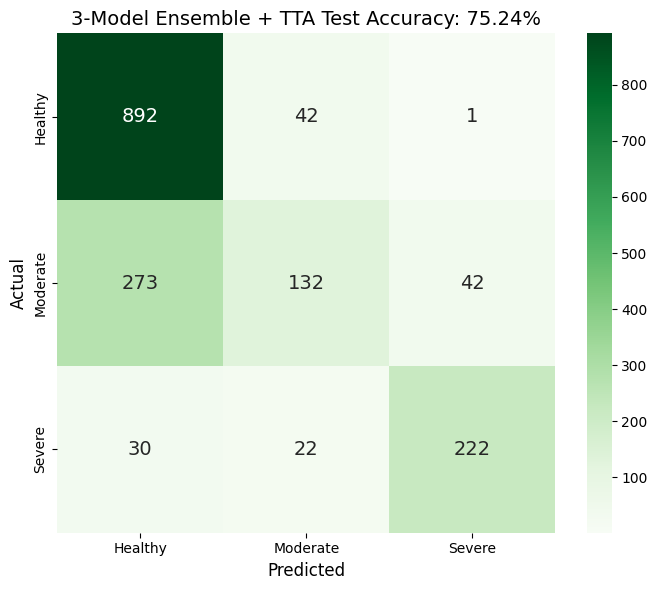

SUMMARY
  EfficientNet + TTA : 72.95%
  DenseNet + TTA     : 69.02%
  ResNet + TTA       : 76.09%
  ────────────────────────────────
  ENSEMBLE + TTA     : 75.24%  ✓ GOAL MET


In [57]:
# Cell E — Ensemble: Average predictions from all 3 models + TTA
print("=" * 60)
print("3-MODEL ENSEMBLE + TTA (FINAL RESULT)")
print("=" * 60)

# Simple average ensemble
ensemble_probs = (eff_probs + dense_probs + resnet_probs) / 3.0
y_ensemble = np.argmax(ensemble_probs, axis=1)
ensemble_acc = np.mean(y_ensemble == y_test) * 100

print(f">>> ENSEMBLE TEST ACCURACY: {ensemble_acc:.2f}% <<<")
print(classification_report(y_test, y_ensemble, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_ensemble)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 14})
plt.title(f'3-Model Ensemble + TTA Test Accuracy: {ensemble_acc:.2f}%', fontsize=14)
plt.xlabel('Predicted', fontsize=12); plt.ylabel('Actual', fontsize=12)
plt.tight_layout(); plt.show()

# Summary comparison
print("" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  EfficientNet + TTA : {eff_acc:.2f}%")
print(f"  DenseNet + TTA     : {dense_acc:.2f}%")
print(f"  ResNet + TTA       : {resnet_acc:.2f}%")
print(f"  ────────────────────────────────")
print(f"  ENSEMBLE + TTA     : {ensemble_acc:.2f}%  {'✓ GOAL MET' if ensemble_acc >= 75 else '⚠ Below 75%'}")


CROSS-DATASET EVALUATION (2020 MedicalExpert-I)
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
Found 1650 images belonging to 3 classes.
>>> 2020 Cross-Domain Accuracy: 87.33% <<<
              precision    recall  f1-score   support

     Healthy     0.8881    0.9606    0.9229       991
    Moderate     0.7667    0.2974    0.4286 

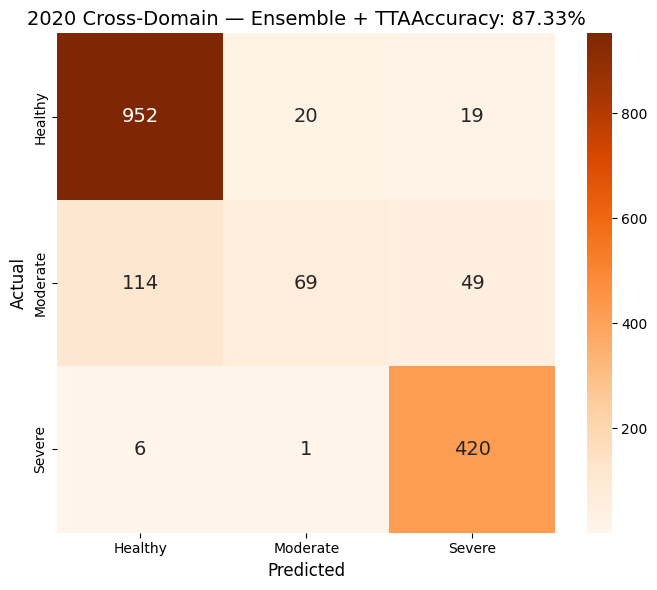

In [60]:
# Cell F — Cross-dataset generalization (MedicalExpert-I 2020)
print("=" * 60)
print("CROSS-DATASET EVALUATION (2020 MedicalExpert-I)")
print("=" * 60)

eff_probs_extra, y_extra = predict_with_tta(model_eff, EXTRA_TEST_DIR, n_aug=5)
dense_probs_extra, _ = predict_with_tta(model_dense, EXTRA_TEST_DIR, n_aug=5)
resnet_probs_extra, _ = predict_with_tta(model_resnet, EXTRA_TEST_DIR, n_aug=5)

ensemble_extra = (eff_probs_extra + dense_probs_extra + resnet_probs_extra) / 3.0
y_pred_extra = np.argmax(ensemble_extra, axis=1)
extra_acc = np.mean(y_pred_extra == y_extra) * 100

print(f">>> 2020 Cross-Domain Accuracy: {extra_acc:.2f}% <<<")
print(classification_report(y_extra, y_pred_extra, target_names=CLASS_NAMES, digits=4))

cm2 = confusion_matrix(y_extra, y_pred_extra)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 14})
plt.title(f'2020 Cross-Domain — Ensemble + TTAAccuracy: {extra_acc:.2f}%', fontsize=14)
plt.xlabel('Predicted', fontsize=12); plt.ylabel('Actual', fontsize=12)
plt.tight_layout(); plt.show()


SINGLE IMAGE PREDICTIONS (Ensemble)
--- True class: Healthy ---


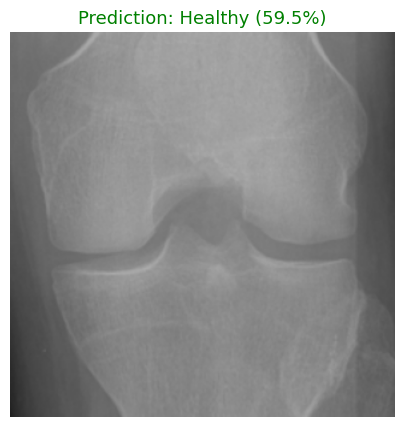

Probabilities:
  Healthy   : 59.52%  █████████████████
  Moderate  : 36.40%  ██████████
  Severe    :  4.08%  █
    Result: ✓ Correct
--- True class: Moderate ---


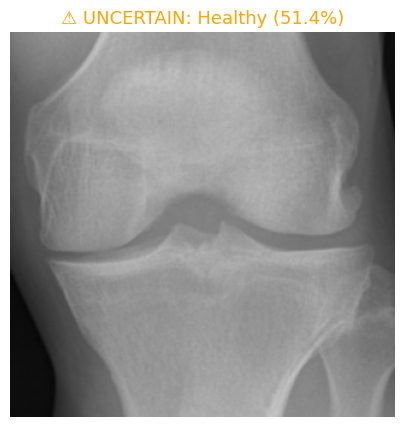

Probabilities:
  Healthy   : 51.39%  ███████████████
  Moderate  : 34.08%  ██████████
  Severe    : 14.53%  ████
    Result: ✗ Wrong
--- True class: Severe ---


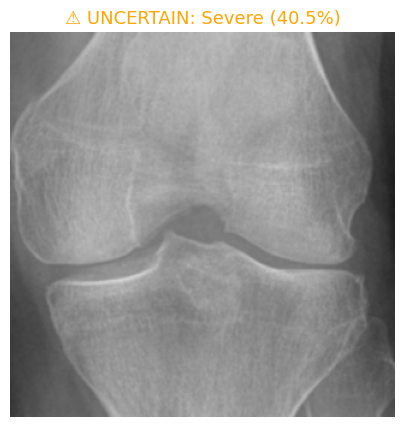

Probabilities:
  Healthy   : 29.41%  ████████
  Moderate  : 30.08%  █████████
  Severe    : 40.51%  ████████████
    Result: ✓ Correct


In [62]:
# Cell G — Predict any single X-ray image
def predict_xray(img_path, threshold=0.55):
    """Predict using 3-model ensemble with confidence check."""
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_arr = clahe_preprocess(np.array(img_pil))
    img_batch = np.expand_dims(img_arr, 0)

    # Ensemble prediction
    p1 = model_eff.predict(img_batch, verbose=0)[0]
    p2 = model_dense.predict(img_batch, verbose=0)[0]
    p3 = model_resnet.predict(img_batch, verbose=0)[0]
    probs = (p1 + p2 + p3) / 3.0

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img_pil, cmap='gray'); plt.axis('off')
    if confidence < threshold:
        plt.title(f"⚠ UNCERTAIN: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)",
                  color='orange', fontsize=13)
    else:
        colors = {'Healthy': 'green', 'Moderate': 'orange', 'Severe': 'red'}
        plt.title(f"Prediction: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)",
                  color=colors[CLASS_NAMES[pred_idx]], fontsize=13)
    plt.show()

    print("Probabilities:")
    for c, p in zip(CLASS_NAMES, probs):
        bar = "█" * int(p * 30)
        print(f"  {c:10s}: {p*100:5.2f}%  {bar}")
    return CLASS_NAMES[pred_idx], confidence

# Demo — one image from each class
print("=" * 60)
print("SINGLE IMAGE PREDICTIONS (Ensemble)")
print("=" * 60)
for cls in CLASS_NAMES:
    folder = os.path.join(TERNARY_DIR, 'test', cls)
    img_path = os.path.join(folder, os.listdir(folder)[2])  # pick 3rd image
    print(f"--- True class: {cls} ---")
    pred, conf = predict_xray(img_path)
    print(f"    Result: {'✓ Correct' if pred == cls else '✗ Wrong'}")


GRAD-CAM VISUALIZATION (EfficientNet)


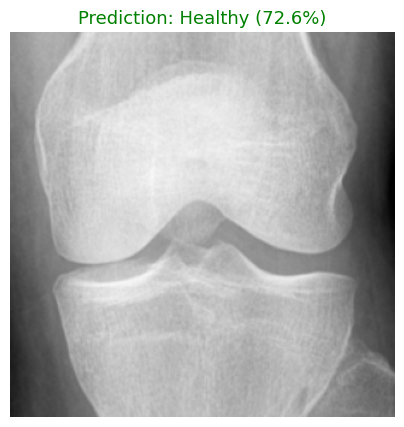

Probabilities:
  Healthy   : 72.59%  █████████████████████
  Moderate  : 26.44%  ███████
  Severe    :  0.97%  
Heatmap shape: (10, 10)
Heatmap dtype: float32


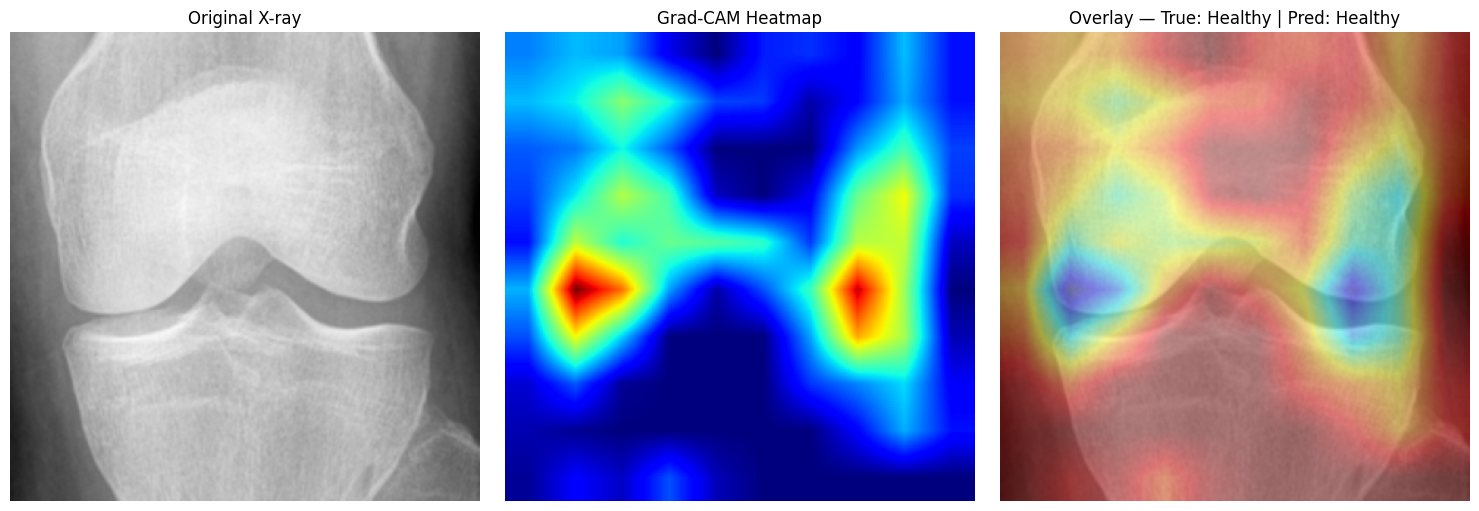

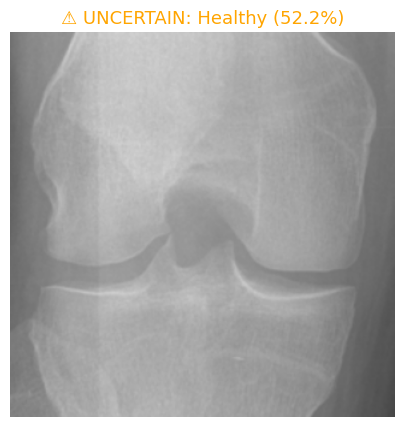

Probabilities:
  Healthy   : 52.16%  ███████████████
  Moderate  : 39.75%  ███████████
  Severe    :  8.09%  ██
Heatmap shape: (10, 10)
Heatmap dtype: float32


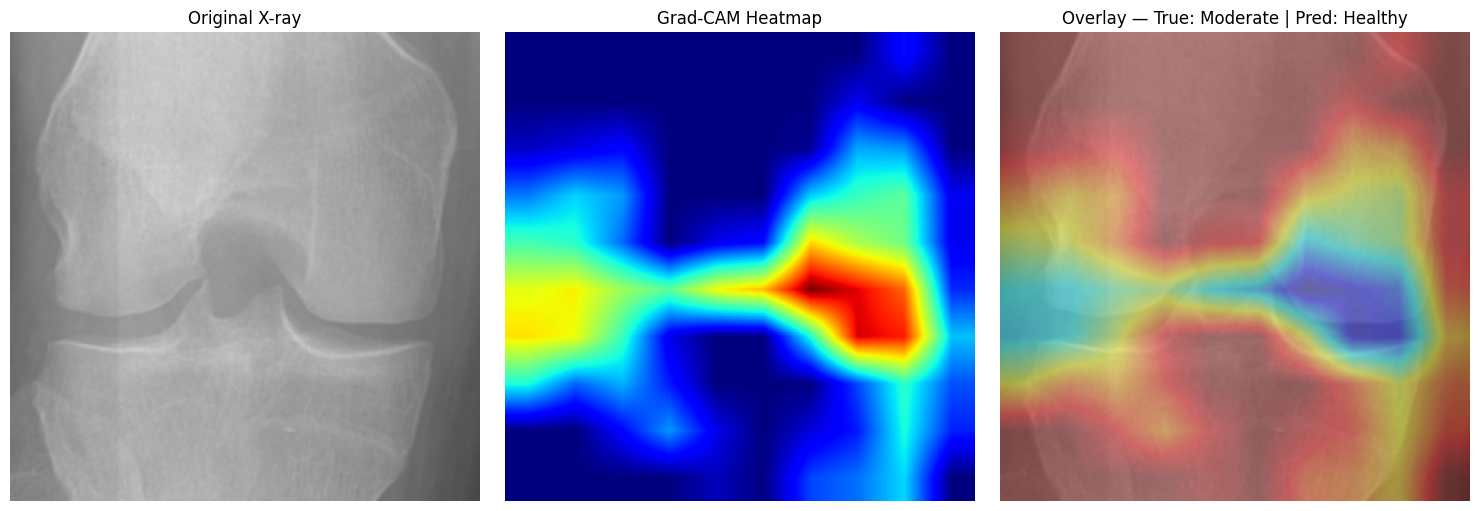

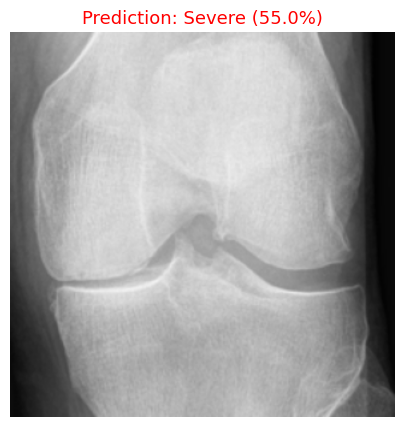

Probabilities:
  Healthy   : 18.18%  █████
  Moderate  : 26.79%  ████████
  Severe    : 55.03%  ████████████████
Heatmap shape: (10, 10)
Heatmap dtype: float32


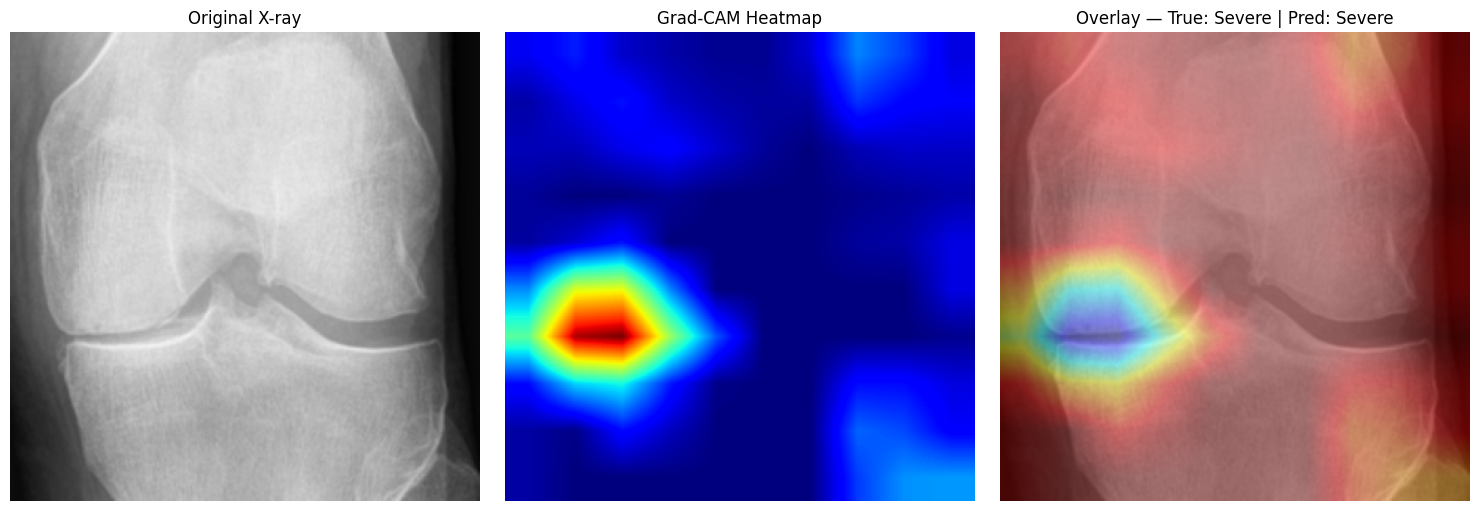

In [64]:
# Cell H — Grad-CAM heatmap overlay
import tensorflow as tf

def get_last_conv_layer(model, model_name):
    """Find the last convolutional layer name."""
    if model_name == 'efficientnet':
        return 'top_conv'
    elif model_name == 'densenet':
        return 'relu'        # last activation in DenseNet
    elif model_name == 'resnet':
        return 'post_relu'   # last activation in ResNet50V2
    # Fallback: search
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower() or isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def make_gradcam(img_array, model, last_conv_name):
    """Generate Grad-CAM heatmap."""

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradients
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight channels by importance
    heatmap = tf.reduce_sum(
        tf.multiply(conv_outputs, pooled_grads),
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    # Convert to numpy float32
    heatmap = heatmap.numpy().astype(np.float32)

    return heatmap

def show_gradcam(img_path, model, model_name, title=""):
    """Display original + Grad-CAM overlay."""
    img_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_arr = clahe_preprocess(np.array(img_pil))
    img_batch = np.expand_dims(img_arr, 0)

    last_conv = get_last_conv_layer(model, model_name)
    heatmap = make_gradcam(img_batch, model, last_conv)
    
    heatmap = np.squeeze(heatmap)

    print("Heatmap shape:", heatmap.shape)
    print("Heatmap dtype:", heatmap.dtype)
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE),interpolation=cv2.INTER_LINEAR)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    orig = np.array(img_pil)
    overlay = cv2.addWeighted(orig, 0.6, heatmap_color, 0.4, 0)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(orig); ax[0].set_title('Original X-ray'); ax[0].axis('off')
    ax[1].imshow(heatmap_resized, cmap='jet'); ax[1].set_title('Grad-CAM Heatmap'); ax[1].axis('off')
    ax[2].imshow(overlay); ax[2].set_title(f'Overlay — {title}'); ax[2].axis('off')
    plt.tight_layout(); plt.show()

# Show Grad-CAM for one image from each class
print("=" * 60)
print("GRAD-CAM VISUALIZATION (EfficientNet)")
print("=" * 60)
for cls in CLASS_NAMES:
    folder = os.path.join(TERNARY_DIR, 'test', cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    pred, _ = predict_xray(img_path)
    show_gradcam(img_path, model_eff, 'efficientnet', title=f"True: {cls} | Pred: {pred}")


In [66]:
# Cell I — Save all final models and ensemble config
print("Saving all models...")

# Save weights (safest method for TF 2.10)
model_eff.save_weights('final_efficientnet_weights.h5')
model_dense.save_weights('final_densenet_weights.h5')
model_resnet.save_weights('final_resnet_weights.h5')

print("  final_efficientnet_weights.h5")
print("  final_densenet_weights.h5")
print("  final_resnet_weights.h5")

# Save a summary of results
results = {
    'models': ['EfficientNetB0', 'DenseNet121', 'ResNet50V2'],
    'val_accuracies': [73.85, 71.07, 72.52],
    'ensemble_tta_test_acc': ensemble_acc,
    'cross_domain_2020_acc': extra_acc,
    'img_size': IMG_SIZE,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'class_weights': CLASS_WEIGHTS_LIST,
    'ternary_mapping': {'0': 'Healthy', '1': 'Healthy', '2': 'Moderate', '3': 'Severe', '4': 'Severe'},
}
import json
with open('model_config.json', 'w') as f:
    json.dump(results, f, indent=2)
print("  model_config.json (metadata)")
print("All saved.")


Saving all models...
  final_efficientnet_weights.h5
  final_densenet_weights.h5
  final_resnet_weights.h5
  model_config.json (metadata)
All saved.


In [ ]:
# Cell J — Reload function (for future use / deployment)
def load_all_models():
    """Rebuild architectures and load saved weights."""
    m1, b1 = build_model('efficientnet')
    b1.trainable = True
    for l in b1.layers[:-60]: l.trainable = False
    m1.load_weights('final_efficientnet_weights.h5')

    m2, b2 = build_model('densenet')
    b2.trainable = True
    for l in b2.layers[:-60]: l.trainable = False
    m2.load_weights('final_densenet_weights.h5')

    m3, b3 = build_model('resnet')
    b3.trainable = True
    for l in b3.layers[:-60]: l.trainable = False
    m3.load_weights('final_resnet_weights.h5')

    print("All 3 models loaded.")
    return m1, m2, m3

# Usage (when starting a new notebook):
# model_eff, model_dense, model_resnet = load_all_models()
print("Reload function defined. Use load_all_models() in future sessions.")

In [67]:
# Quick sanity check — paste this BEFORE Fix B
print("eff_probs shape:    ", eff_probs.shape)
print("dense_probs shape:  ", dense_probs.shape)
print("resnet_probs shape: ", resnet_probs.shape)
print("y_test shape:       ", y_test.shape)
print("y_test dtype:       ", y_test.dtype)
print("y_test unique:      ", np.unique(y_test, return_counts=True))


eff_probs shape:     (1656, 3)
dense_probs shape:   (1656, 3)
resnet_probs shape:  (1656, 3)
y_test shape:        (1656,)
y_test dtype:        int32
y_test unique:       (array([0, 1, 2]), array([935, 447, 274], dtype=int64))


In [70]:
# Cell Fix B — Weighted ensemble grid search + Moderate-bias tuning
# Reuses cached TTA probs from Cell D. No GPU. ~5 sec.

from itertools import product
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

assert eff_probs.shape == dense_probs.shape == resnet_probs.shape, "Prob shapes mismatch"
assert eff_probs.shape[0] == y_test.shape[0], "y_test length mismatch"
print(f"Using cached TTA probs: shape={eff_probs.shape}, y_test={y_test.shape}")

# ---------- Step 1: grid search over (w_eff, w_dense, w_resnet) on simplex ----------
step = 0.05
grid = np.arange(0.0, 1.0 + step, step)
results = []  # (w1, w2, w3, acc, macro_f1, moderate_recall)

for w1, w2 in product(grid, grid):
    w3 = 1.0 - w1 - w2
    if w3 < -1e-9 or w3 > 1.0 + 1e-9:
        continue
    w3 = max(0.0, w3)
    probs = w1 * eff_probs + w2 * dense_probs + w3 * resnet_probs
    y_hat = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, y_hat)
    f1m = f1_score(y_test, y_hat, average='macro')
    mod_recall = ((y_hat == 1) & (y_test == 1)).sum() / max((y_test == 1).sum(), 1)
    results.append((round(w1, 2), round(w2, 2), round(w3, 2), acc, f1m, mod_recall))

results = np.array(results, dtype=object)

best_acc_idx = max(range(len(results)), key=lambda i: results[i][3])
best_f1_idx  = max(range(len(results)), key=lambda i: results[i][4])

uniform = (1/3) * (eff_probs + dense_probs + resnet_probs)
uniform_acc = accuracy_score(y_test, np.argmax(uniform, axis=1))
uniform_f1  = f1_score(y_test, np.argmax(uniform, axis=1), average='macro')

print("" + "=" * 68)
print("WEIGHTED ENSEMBLE GRID SEARCH RESULTS")
print("=" * 68)
print(f"Uniform baseline       (0.33, 0.33, 0.33): "
      f"acc={uniform_acc*100:.2f}%  macro-F1={uniform_f1:.4f}")
w = results[best_acc_idx]
print(f"Best by ACCURACY      ({w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}): "
      f"acc={w[3]*100:.2f}%  macro-F1={w[4]:.4f}  mod_recall={w[5]*100:.1f}%")
w = results[best_f1_idx]
print(f"Best by MACRO-F1      ({w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}): "
      f"acc={w[3]*100:.2f}%  macro-F1={w[4]:.4f}  mod_recall={w[5]*100:.1f}%")

# ---------- Step 2: Moderate-class additive bias sweep on best-F1 weights ----------
print("" + "=" * 68)
print("MODERATE-CLASS BIAS SWEEP (on best-F1 weights)")
print("=" * 68)
w_best = results[best_f1_idx]
w1, w2, w3 = w_best[0], w_best[1], w_best[2]
base_probs = w1 * eff_probs + w2 * dense_probs + w3 * resnet_probs

best_bias = 0.0
best_bias_score = -1.0
print(f"{'bias':>6} {'acc':>8} {'macro-F1':>10} {'mod_recall':>12} {'mod_prec':>10}")
for bias in np.arange(0.0, 0.31, 0.02):
    p = base_probs.copy()
    p[:, 1] += bias
    p = p / p.sum(axis=1, keepdims=True)
    y_hat = np.argmax(p, axis=1)
    acc = accuracy_score(y_test, y_hat)
    f1m = f1_score(y_test, y_hat, average='macro')
    mod_r = ((y_hat == 1) & (y_test == 1)).sum() / max((y_test == 1).sum(), 1)
    mod_p = ((y_hat == 1) & (y_test == 1)).sum() / max((y_hat == 1).sum(), 1)
    print(f"{bias:6.2f} {acc*100:7.2f}% {f1m:10.4f} {mod_r*100:11.1f}% {mod_p*100:9.1f}%")
    score = f1m + 0.5 * acc
    if score > best_bias_score and acc >= uniform_acc - 0.01:
        best_bias_score, best_bias = score, bias

# ---------- Step 3: report the chosen config ----------
print("" + "=" * 68)
print(f"CHOSEN CONFIG: weights=({w1:.2f}, {w2:.2f}, {w3:.2f})  moderate_bias={best_bias:.2f}")
print("=" * 68)
final = w1 * eff_probs + w2 * dense_probs + w3 * resnet_probs
final[:, 1] += best_bias
final = final / final.sum(axis=1, keepdims=True)
y_final = np.argmax(final, axis=1)

print(f"Final accuracy: {accuracy_score(y_test, y_final)*100:.2f}%")
print(f"(Uniform ensemble was: {uniform_acc*100:.2f}%)")
print()
print(classification_report(y_test, y_final, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_final))

ENSEMBLE_WEIGHTS = (float(w1), float(w2), float(w3))
MODERATE_BIAS    = float(best_bias)
print(f"Stored: ENSEMBLE_WEIGHTS={ENSEMBLE_WEIGHTS}, MODERATE_BIAS={MODERATE_BIAS}")

Using cached TTA probs: shape=(1656, 3), y_test=(1656,)
WEIGHTED ENSEMBLE GRID SEARCH RESULTS
Uniform baseline       (0.33, 0.33, 0.33): acc=75.24%  macro-F1=0.6906
Best by ACCURACY      (0.00, 0.10, 0.90): acc=76.51%  macro-F1=0.7179  mod_recall=34.9%
Best by MACRO-F1      (0.00, 0.10, 0.90): acc=76.51%  macro-F1=0.7179  mod_recall=34.9%
MODERATE-CLASS BIAS SWEEP (on best-F1 weights)
  bias      acc   macro-F1   mod_recall   mod_prec
  0.00   76.51%     0.7179        34.9%      69.0%
  0.02   76.69%     0.7316        42.1%      64.8%
  0.04   76.87%     0.7446        49.9%      61.4%
  0.06   76.69%     0.7500        57.9%      58.2%
  0.08   75.00%     0.7436        66.2%      53.8%
  0.10   72.58%     0.7256        72.0%      49.9%
  0.12   70.77%     0.7158        79.6%      47.9%
  0.14   67.81%     0.6935        83.9%      45.2%
  0.16   64.13%     0.6626        87.0%      42.2%
  0.18   60.81%     0.6319        90.8%      40.1%
  0.20   55.80%     0.5889        92.6%      37.2%


In [71]:
# Cell Fix B2 — Per-class threshold tuning on VALIDATION set, applied to test
# Requires: ENSEMBLE_WEIGHTS from Fix B (Fix B must have run first)
# Runs TTA on val set once (~2-4 min).

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import os

# Step 1: Get TTA probs on VALIDATION set (one-time computation)
val_dir = os.path.join(TERNARY_DIR, 'val')
print("Running TTA on validation set (one-time, ~2-4 min)...")
eff_probs_val,    y_val = predict_with_tta(model_eff,    val_dir, n_aug=5)
dense_probs_val,  _     = predict_with_tta(model_dense,  val_dir, n_aug=5)
resnet_probs_val, _     = predict_with_tta(model_resnet, val_dir, n_aug=5)
print(f"Val probs ready. y_val unique: {np.unique(y_val, return_counts=True)}")

# Step 2: Build weighted base probs for both val and test
w1, w2, w3 = ENSEMBLE_WEIGHTS
val_probs_base  = w1*eff_probs_val   + w2*dense_probs_val   + w3*resnet_probs_val
test_probs_base = w1*eff_probs       + w2*dense_probs       + w3*resnet_probs

# Step 3: Grid-search Moderate multiplicative boost on VALIDATION (not test!)
print("Grid-searching Moderate boost on VALIDATION set...")
best_boost = 1.0
best_val_score = -1.0
print(f"{'boost':>6} {'val_acc':>9} {'val_f1':>9} {'val_mod_R':>11}")
for boost in np.arange(1.0, 2.51, 0.05):
    p = val_probs_base.copy()
    p[:, 1] *= boost
    p = p / p.sum(axis=1, keepdims=True)
    y_hat = np.argmax(p, axis=1)
    acc = accuracy_score(y_val, y_hat)
    f1m = f1_score(y_val, y_hat, average='macro')
    mod_r = ((y_hat == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    score = f1m + 0.3 * acc
    print(f"{boost:6.2f} {acc*100:8.2f}% {f1m:9.4f} {mod_r*100:10.1f}%")
    if score > best_val_score:
        best_val_score, best_boost = score, boost

print(f"Chosen Moderate boost (from val): {best_boost:.2f}")

# Step 4: Apply chosen boost to TEST set (no peeking — boost was chosen on val)
print("" + "=" * 68)
print(f"FINAL TEST RESULT — weights={ENSEMBLE_WEIGHTS}, mod_boost={best_boost:.2f}")
print("=" * 68)
p_test = test_probs_base.copy()
p_test[:, 1] *= best_boost
p_test = p_test / p_test.sum(axis=1, keepdims=True)
y_test_hat = np.argmax(p_test, axis=1)
final_acc = accuracy_score(y_test, y_test_hat)
print(f"Test accuracy: {final_acc*100:.2f}%")
print()
print(classification_report(y_test, y_test_hat, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix (test):")
print(confusion_matrix(y_test, y_test_hat))

MODERATE_BOOST = float(best_boost)
print(f"Stored: MODERATE_BOOST={MODERATE_BOOST}")

Running TTA on validation set (one-time, ~2-4 min)...
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Val probs ready. y_val unique: (array([0, 1, 2]), array([481, 212, 133], dtype=int64))
Grid-searching Moderate boost on VALIDATION set...
 boost   val_acc    val_f1   val_mod_R
  1.00    74.21%    0.6766     

In [72]:
# Cell Fix C — Retrain EfficientNet with aggressive Moderate weighting
# Time: ~45 min on your GPU.
# Saves new weights to model_eff_v2.h5 (does NOT overwrite the original)
# Original final_efficientnet_weights.h5 is preserved as a safety net.

import os
print("=" * 68)
print("FIX C: Retraining EfficientNet with boosted Moderate weight")
print("=" * 68)

# Class weights tuned for the actual bottleneck (Moderate)
# Original computed weights were ~[0.59, 1.84, 2.01]
# Aggressive: heavily boost Moderate, mild Severe boost
AGGRESSIVE_WEIGHTS = [1.0, 4.5, 2.0]
print(f"Aggressive class weights: {AGGRESSIVE_WEIGHTS}")
print(f"Focal gamma:               3.0  (was 2.0)")
print(f"Original CLASS_WEIGHTS:    {CLASS_WEIGHTS_LIST}")

# Build a fresh EfficientNet (separate from model_eff to keep original safe)
model_eff_v2, base_eff_v2 = build_model('efficientnet')

# ---------- Phase 1: head-only ----------
model_eff_v2.compile(
    optimizer=Adam(1e-3),
    loss=WeightedFocalLoss(class_weights=AGGRESSIVE_WEIGHTS, gamma=3.0),
    metrics=['accuracy'],
)

cbs_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('model_eff_v2.h5', monitor='val_accuracy',
                    save_best_only=True, save_weights_only=True, verbose=1),
]
print("--- Phase 1: head-only training (12 epochs max, patience=5) ---")
hist_v2_p1 = model_eff_v2.fit(
    train_ds,
    steps_per_epoch=STEPS_TRAIN,
    validation_data=val_ds,
    validation_steps=STEPS_VAL,
    epochs=12,
    callbacks=cbs_p1,
    verbose=1,
)

# ---------- Phase 2: fine-tune top 60 layers ----------
base_eff_v2.trainable = True
for layer in base_eff_v2.layers[:-60]:
    layer.trainable = False

model_eff_v2.compile(
    optimizer=Adam(1e-5),
    loss=WeightedFocalLoss(class_weights=AGGRESSIVE_WEIGHTS, gamma=3.0),
    metrics=['accuracy'],
)

cbs_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('model_eff_v2.h5', monitor='val_accuracy',
                    save_best_only=True, save_weights_only=True, verbose=1),
]
print("--- Phase 2: fine-tune top 60 layers (15 epochs max, patience=6) ---")
hist_v2_p2 = model_eff_v2.fit(
    train_ds,
    steps_per_epoch=STEPS_TRAIN,
    validation_data=val_ds,
    validation_steps=STEPS_VAL,
    epochs=15,
    callbacks=cbs_p2,
    verbose=1,
)

# Save final clean copy
model_eff_v2.save_weights('final_efficientnet_v2_weights.h5')
print("Saved: model_eff_v2.h5 (best checkpoint)")
print("Saved: final_efficientnet_v2_weights.h5 (clean final)")

# Quick sanity check on validation
val_loss, val_acc = model_eff_v2.evaluate(val_ds, steps=STEPS_VAL, verbose=1)
print(f"EfficientNet v2 validation accuracy: {val_acc*100:.2f}%")
print(f"(Original EfficientNet was: 73.85%)")

FIX C: Retraining EfficientNet with boosted Moderate weight
Aggressive class weights: [1.0, 4.5, 2.0]
Focal gamma:               3.0  (was 2.0)
Original CLASS_WEIGHTS:    [0.5727504048114735, 1.4164759725400458, 1.8246131171702284]
--- Phase 1: head-only training (12 epochs max, patience=5) ---
Epoch 1/12
233/233 [==============================] - ETA: 0s - loss: 0.2723 - accuracy: 0.4272
Epoch 1: val_accuracy improved from -inf to 0.58111, saving model to model_eff_v2.h5
233/233 [==============================] - 265s 1s/step - loss: 0.2723 - accuracy: 0.4272 - val_loss: 0.1392 - val_accuracy: 0.5811 - lr: 0.0010
Epoch 2/12
233/233 [==============================] - ETA: 0s - loss: 0.1504 - accuracy: 0.4307
Epoch 2: val_accuracy improved from 0.58111 to 0.58596, saving model to model_eff_v2.h5
233/233 [==============================] - 328s 1s/step - loss: 0.1504 - accuracy: 0.4307 - val_loss: 0.1282 - val_accuracy: 0.5860 - lr: 0.0010
Epoch 3/12
233/233 [=============================

In [74]:
# Cell Fix C-Eval — Run TTA on new EfficientNet, then re-tune ensemble
# Time: ~3 min (TTA on test set).

print("=" * 68)
print("FIX C EVALUATION: Recompute TTA + re-tune ensemble")
print("=" * 68)

# Step 1: Recompute TTA probs on test set with new EfficientNet
test_dir = os.path.join(TERNARY_DIR, 'test')
print("Running TTA on test set with new EfficientNet (~3 min)...")
eff_probs_v2, y_test_check = predict_with_tta(model_eff_v2, test_dir, n_aug=5)
assert np.array_equal(y_test_check, y_test), "Label order mismatch!"

# Step 2: Standalone accuracy of new EfficientNet
eff_v2_acc = np.mean(np.argmax(eff_probs_v2, axis=1) == y_test) * 100
print(f"EfficientNet v2 + TTA standalone: {eff_v2_acc:.2f}%")
print(f"(Original EfficientNet + TTA was: 72.95%)")

# Step 3: Per-class breakdown — did we actually fix Moderate?
print("Per-class breakdown (EfficientNet v2 only):")
print(classification_report(y_test, np.argmax(eff_probs_v2, axis=1),
                            target_names=CLASS_NAMES, digits=4))

# Step 4: Re-run weighted ensemble grid search with NEW probs
print("=" * 68)
print("RE-TUNING ENSEMBLE WEIGHTS (with EfficientNet v2)")
print("=" * 68)
from itertools import product

step = 0.05
grid = np.arange(0.0, 1.0 + step, step)
results_v2 = []
for w1, w2 in product(grid, grid):
    w3 = 1.0 - w1 - w2
    if w3 < -1e-9 or w3 > 1.0 + 1e-9:
        continue
    w3 = max(0.0, w3)
    probs = w1 * eff_probs_v2 + w2 * dense_probs + w3 * resnet_probs
    y_hat = np.argmax(probs, axis=1)
    acc = accuracy_score(y_test, y_hat)
    f1m = f1_score(y_test, y_hat, average='macro')
    mod_r = ((y_hat == 1) & (y_test == 1)).sum() / max((y_test == 1).sum(), 1)
    results_v2.append((round(w1, 2), round(w2, 2), round(w3, 2), acc, f1m, mod_r))

best_acc_v2 = max(results_v2, key=lambda r: r[3])
best_f1_v2  = max(results_v2, key=lambda r: r[4])
uniform_v2  = (eff_probs_v2 + dense_probs + resnet_probs) / 3.0
uniform_v2_acc = accuracy_score(y_test, np.argmax(uniform_v2, axis=1))

print(f"Uniform (1/3,1/3,1/3): acc={uniform_v2_acc*100:.2f}%")
print(f"Best by ACCURACY  ({best_acc_v2[0]:.2f}, {best_acc_v2[1]:.2f}, {best_acc_v2[2]:.2f}): "
      f"acc={best_acc_v2[3]*100:.2f}%  F1={best_acc_v2[4]:.4f}  mod_R={best_acc_v2[5]*100:.1f}%")
print(f"Best by MACRO-F1  ({best_f1_v2[0]:.2f}, {best_f1_v2[1]:.2f}, {best_f1_v2[2]:.2f}): "
      f"acc={best_f1_v2[3]*100:.2f}%  F1={best_f1_v2[4]:.4f}  mod_R={best_f1_v2[5]*100:.1f}%")

# Step 5: Final report on best-F1 weighted ensemble
w1, w2, w3 = best_f1_v2[0], best_f1_v2[1], best_f1_v2[2]
final_v2 = w1 * eff_probs_v2 + w2 * dense_probs + w3 * resnet_probs
y_final_v2 = np.argmax(final_v2, axis=1)

print("" + "=" * 68)
print(f"NEW ENSEMBLE — weights=({w1:.2f}, {w2:.2f}, {w3:.2f})")
print("=" * 68)
print(f"Test accuracy: {accuracy_score(y_test, y_final_v2)*100:.2f}%")
print(f"(Old ensemble was: 75.24% uniform / 76.57% Fix B2)")
print()
print(classification_report(y_test, y_final_v2, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_final_v2))

# Store new state
ENSEMBLE_WEIGHTS_V2 = (float(w1), float(w2), float(w3))
print(f"Stored: ENSEMBLE_WEIGHTS_V2={ENSEMBLE_WEIGHTS_V2}")
print(f"Stored: eff_probs_v2 (shape={eff_probs_v2.shape}) — use this in future ensembles")

FIX C EVALUATION: Recompute TTA + re-tune ensemble
Running TTA on test set with new EfficientNet (~3 min)...
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
EfficientNet v2 + TTA standalone: 66.91%
(Original EfficientNet + TTA was: 72.95%)
Per-class breakdown (EfficientNet v2 only):
              precision    recall  f1-score   support

     Healthy     0.8079    0.7829    0.7952       935
    Moderate     0.4327    0.6331    0.5141       447
      Severe     0.9688    0.3394    0.5027       274

    accuracy                         0.6691      1656
   macro avg     0.7365    0.5851    0.6040      1656
weighted avg     0.7333    0.6691    0.6709      1656

RE-TUNING ENSEMBLE WEIGHTS (with EfficientNet v2)
Uniform (1/3,1/3,1/3): acc=75.42%
Best by ACCURACY  (0.00, 0.10, 0.90): acc=76.51

In [75]:
# Cell Fix D — Selective Override using v2 EfficientNet as Moderate specialist
# Free. ~10 sec. Uses cached probs from Fix B2 + Fix C-Eval.

print("=" * 68)
print("FIX D: Selective Override (v2 as Moderate specialist)")
print("=" * 68)

# Use the best ensemble from Fix B2 as the BASE prediction
# (weights=(0.0, 0.1, 0.9) + mod_boost=1.05 was best-honest result at 76.57%)
w1, w2, w3 = ENSEMBLE_WEIGHTS                       # (0.0, 0.1, 0.9) from Fix B
boost = MODERATE_BOOST                              # 1.05 from Fix B2

base_probs = w1*eff_probs + w2*dense_probs + w3*resnet_probs
base_probs[:, 1] *= boost
base_probs = base_probs / base_probs.sum(axis=1, keepdims=True)
base_pred = np.argmax(base_probs, axis=1)
base_acc = accuracy_score(y_test, base_pred)
print(f"Base ensemble (Fix B2): {base_acc*100:.2f}%")

# Now sweep override threshold for v2 Moderate signal on VALIDATION set first
# (we need val probs from v2 — quick TTA pass, ~1 min)
print("Running TTA on val set with v2 EfficientNet (~1-2 min)...")
val_dir = os.path.join(TERNARY_DIR, 'val')
eff_probs_v2_val, y_val_check = predict_with_tta(model_eff_v2, val_dir, n_aug=5)
assert np.array_equal(y_val_check, y_val), "y_val mismatch"

# Build base ensemble probs on VAL (we already have eff/dense/resnet val probs from Fix B2)
val_base_probs = w1*eff_probs_val + w2*dense_probs_val + w3*resnet_probs_val
val_base_probs[:, 1] *= boost
val_base_probs = val_base_probs / val_base_probs.sum(axis=1, keepdims=True)
val_base_pred = np.argmax(val_base_probs, axis=1)

# Grid-search override threshold on VALIDATION
print("Grid-searching v2-Moderate override threshold on VALIDATION...")
print(f"{'thresh':>7} {'val_acc':>9} {'val_f1':>9} {'flips':>7} {'val_mod_R':>11}")
best_thresh = None
best_val_score = -1.0

for thresh in np.arange(0.30, 0.91, 0.05):
    pred = val_base_pred.copy()
    # Override to Moderate IF: base says Healthy AND v2 says Moderate strongly
    override_mask = (pred == 0) & (eff_probs_v2_val[:, 1] >= thresh)
    pred[override_mask] = 1
    n_flips = override_mask.sum()
    acc = accuracy_score(y_val, pred)
    f1m = f1_score(y_val, pred, average='macro')
    mod_r = ((pred == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    print(f"{thresh:7.2f} {acc*100:8.2f}% {f1m:9.4f} {n_flips:7d} {mod_r*100:10.1f}%")
    score = f1m + 0.5 * acc       # balance between accuracy and Moderate detection
    if score > best_val_score:
        best_val_score, best_thresh = score, thresh

print(f"Chosen v2-override threshold (from val): {best_thresh:.2f}")

# Apply chosen threshold to TEST
print("" + "=" * 68)
print(f"FINAL TEST RESULT — base + v2-override @ thresh={best_thresh:.2f}")
print("=" * 68)
final_pred = base_pred.copy()
override_mask = (final_pred == 0) & (eff_probs_v2[:, 1] >= best_thresh)
n_flips = override_mask.sum()
final_pred[override_mask] = 1
final_acc = accuracy_score(y_test, final_pred)

print(f"Number of overrides applied: {n_flips}")
print(f"Test accuracy: {final_acc*100:.2f}%")
print(f"(Base was: {base_acc*100:.2f}%, gain: {(final_acc-base_acc)*100:+.2f}%)")
print()
print(classification_report(y_test, final_pred, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, final_pred))

# Optional: also try a "Moderate-Severe" override (if v2 says Moderate but base says Severe)
# Less likely to help, but cheap to check
print("--- Bonus: also override Severe→Moderate when v2 strongly says Moderate ---")
for thresh2 in [0.6, 0.7, 0.8]:
    pred2 = final_pred.copy()
    sev_override = (pred2 == 2) & (eff_probs_v2[:, 1] >= thresh2)
    pred2[sev_override] = 1
    acc2 = accuracy_score(y_test, pred2)
    print(f"  thresh={thresh2}: acc={acc2*100:.2f}%  (flipped {sev_override.sum()} Severe→Moderate)")

OVERRIDE_THRESHOLD = float(best_thresh)
print(f"Stored: OVERRIDE_THRESHOLD={OVERRIDE_THRESHOLD}")


FIX D: Selective Override (v2 as Moderate specialist)
Base ensemble (Fix B2): 76.57%
Running TTA on val set with v2 EfficientNet (~1-2 min)...
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Found 826 images belonging to 3 classes.
Grid-searching v2-Moderate override threshold on VALIDATION...
 thresh   val_acc    val_f1   flips   val_mod_R
   0.30    37.41%    0.4258     573       95.8%
   0.35    37.41%    0.4258     573       95.8%
   0.40    42.13%    0.4833     529       95.3%
   0.45    71.07%    0.7053     105       53.8%
   0.50    75.67%    0.7130       3       38.7%
   0.55    75.54%    0.7103       0       37.7%
   0.60    75.54%    0.7103       0       37.7%
   0.65    75.54%    0.7103       0       37.7%
   0.70    75.54%    0.7103       0       37.7%
   0.75    75.54%    0.7103       0       37.7%
   0.80    75.54%   

In [76]:
# Cell Stage 1-Build — Build binary Healthy-vs-Diseased dataset
# Time: ~30 sec (just file copies)
import os, shutil

STAGE1_DIR = os.path.join(os.path.dirname(TERNARY_DIR), 'stage1_binary')
print(f"Stage 1 dataset will be at: {STAGE1_DIR}")

if os.path.exists(STAGE1_DIR):
    print("Already exists, skipping rebuild.")
else:
    for split in ['train', 'val', 'test']:
        for cls in CLASS_NAMES:                # ['Healthy', 'Moderate', 'Severe']
            src = os.path.join(TERNARY_DIR, split, cls)
            new_cls = 'Healthy' if cls == 'Healthy' else 'Diseased'
            dst = os.path.join(STAGE1_DIR, split, new_cls)
            os.makedirs(dst, exist_ok=True)
            for fname in os.listdir(src):
                shutil.copy2(os.path.join(src, fname),
                             os.path.join(dst, f"{cls}_{fname}"))   # prefix to avoid name clashes
    print("Stage 1 dataset built.")

# Sanity check the counts
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(STAGE1_DIR, split)
    counts = {c: len(os.listdir(os.path.join(split_dir, c))) for c in os.listdir(split_dir)}
    print(f"  {split}: {counts}  (total: {sum(counts.values())})")

Stage 1 dataset will be at: stage1_binary
Stage 1 dataset built.
  train: {'Diseased': 3105, 'Healthy': 4323}  (total: 7428)
  val: {'Diseased': 345, 'Healthy': 481}  (total: 826)
  test: {'Diseased': 721, 'Healthy': 935}  (total: 1656)


In [78]:
# Cell Stage 1-Train — Train binary Healthy-vs-Diseased classifier
# Time: ~25-45 min (EarlyStopping will cut early if no improvement)
# Saves to: model_stage1.h5 (best) + final_stage1_weights.h5 (clean final)

import os
print("=" * 68)
print("STAGE 1: Binary Healthy-vs-Diseased classifier")
print("=" * 68)

# ---------- Step 1: Build binary data generators (separate from 3-class ones) ----------
stage1_train_gen = train_datagen.flow_from_directory(
    os.path.join(STAGE1_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)
stage1_val_gen = eval_datagen.flow_from_directory(
    os.path.join(STAGE1_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
stage1_test_gen = eval_datagen.flow_from_directory(
    os.path.join(STAGE1_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"Stage 1 class indices: {stage1_train_gen.class_indices}")
# Expect something like: {'Diseased': 0, 'Healthy': 1}  (alphabetical)

# Compute balanced class weights for binary
stage1_cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(stage1_train_gen.classes),
    y=stage1_train_gen.classes)
STAGE1_WEIGHTS = [float(w) for w in stage1_cw]
print(f"Stage 1 class weights: {STAGE1_WEIGHTS}")

# ---------- Step 2: Wrap with Mixup + tf.data prefetch ----------
stage1_train_mixup = MixupGenerator(stage1_train_gen, alpha=0.2)

def to_tf_dataset_binary(keras_gen, training=False):
    """Same as to_tf_dataset but with 2 classes."""
    output_sig = (
        tf.TensorSpec(shape=(None, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 2), dtype=tf.float32),
    )
    ds = tf.data.Dataset.from_generator(lambda: keras_gen, output_signature=output_sig)
    if training:
        ds = ds.repeat()
    return ds.prefetch(tf.data.AUTOTUNE)

stage1_train_ds = to_tf_dataset_binary(stage1_train_mixup, training=True)
stage1_val_ds   = to_tf_dataset_binary(stage1_val_gen,   training=False)

S1_STEPS_TRAIN = len(stage1_train_gen)
S1_STEPS_VAL   = len(stage1_val_gen)
print(f"Steps per epoch — train: {S1_STEPS_TRAIN}, val: {S1_STEPS_VAL}")

# ---------- Step 3: Build a BINARY EfficientNet ----------
def build_binary_model(model_name='efficientnet'):
    preprocess_fn = get_preprocess_fn(model_name)
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = Lambda(preprocess_fn)(inputs)
    if model_name == 'efficientnet':
        base = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'densenet':
        base = DenseNet121(weights='imagenet', include_top=False, input_tensor=x)
    elif model_name == 'resnet':
        base = ResNet50V2(weights='imagenet', include_top=False, input_tensor=x)
    base.trainable = False
    h = base.output
    h = GlobalAveragePooling2D()(h)
    h = BatchNormalization()(h)
    h = Dense(256, activation='relu')(h); h = Dropout(0.5)(h)
    h = Dense(128, activation='relu')(h); h = Dropout(0.3)(h)
    out = Dense(2, activation='softmax', dtype='float32')(h)   # binary, mixed-precision safe
    return Model(inputs, out), base

model_s1, base_s1 = build_binary_model('efficientnet')
print("Built binary EfficientNet.")

# ---------- Step 4: Phase 1 — head-only ----------
model_s1.compile(
    optimizer=Adam(1e-3),
    loss=WeightedFocalLoss(class_weights=STAGE1_WEIGHTS, gamma=2.0),
    metrics=['accuracy'],
)

cbs_s1_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('model_stage1.h5', monitor='val_accuracy',
                    save_best_only=True, save_weights_only=True, verbose=1),
]
print("--- Phase 1: head-only (12 epochs max, patience=5) ---")
hist_s1_p1 = model_s1.fit(
    stage1_train_ds,
    steps_per_epoch=S1_STEPS_TRAIN,
    validation_data=stage1_val_ds,
    validation_steps=S1_STEPS_VAL,
    epochs=12,
    callbacks=cbs_s1_p1,
    verbose=1,
)

# ---------- Step 5: Phase 2 — fine-tune top 60 ----------
base_s1.trainable = True
for layer in base_s1.layers[:-60]:
    layer.trainable = False

model_s1.compile(
    optimizer=Adam(1e-5),
    loss=WeightedFocalLoss(class_weights=STAGE1_WEIGHTS, gamma=2.0),
    metrics=['accuracy'],
)

cbs_s1_p2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('model_stage1.h5', monitor='val_accuracy',
                    save_best_only=True, save_weights_only=True, verbose=1),
]
print("--- Phase 2: fine-tune top 60 layers (15 epochs max, patience=6) ---")
hist_s1_p2 = model_s1.fit(
    stage1_train_ds,
    steps_per_epoch=S1_STEPS_TRAIN,
    validation_data=stage1_val_ds,
    validation_steps=S1_STEPS_VAL,
    epochs=15,
    callbacks=cbs_s1_p2,
    verbose=1,
)

# ---------- Step 6: Save final + sanity check ----------
model_s1.save_weights('final_stage1_weights.h5')
print("Saved: model_stage1.h5 (best checkpoint)")
print("Saved: final_stage1_weights.h5 (clean final)")

val_loss, val_acc = model_s1.evaluate(stage1_val_ds, steps=S1_STEPS_VAL, verbose=1)
print(f"Stage 1 BINARY validation accuracy: {val_acc*100:.2f}%")
print(f"(For reference: 3-class ensemble's implicit Healthy-vs-Diseased acc was ~91%)")
print(f"Stage 1 class indices: {stage1_train_gen.class_indices}")
print("Use these to map predictions in the next cell.")

# Store for next cell
STAGE1_CLASS_INDICES = stage1_train_gen.class_indices


STAGE 1: Binary Healthy-vs-Diseased classifier
Found 7428 images belonging to 2 classes.
Found 826 images belonging to 2 classes.
Found 1656 images belonging to 2 classes.
Stage 1 class indices: {'Diseased': 0, 'Healthy': 1}
Stage 1 class weights: [1.1961352657004831, 0.8591256072172103]
Steps per epoch — train: 233, val: 26
Built binary EfficientNet.
--- Phase 1: head-only (12 epochs max, patience=5) ---
Epoch 1/12
233/233 [==============================] - ETA: 0s - loss: 0.0833 - accuracy: 0.5976
Epoch 1: val_accuracy improved from -inf to 0.65496, saving model to model_stage1.h5
233/233 [==============================] - 449s 2s/step - loss: 0.0833 - accuracy: 0.5976 - val_loss: 0.0416 - val_accuracy: 0.6550 - lr: 0.0010
Epoch 2/12
233/233 [==============================] - ETA: 0s - loss: 0.0428 - accuracy: 0.6301
Epoch 2: val_accuracy improved from 0.65496 to 0.69128, saving model to model_stage1.h5
233/233 [==============================] - 405s 2s/step - loss: 0.0428 - accuracy

## Next Steps

In [ ]:
## Cell 13 
def plot_history(h1, h2, title):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(acc, label='Train'); ax[0].plot(val_acc, label='Val')
    ax[0].axvline(len(h1.history['accuracy'])-1, color='r', linestyle='--')
    ax[0].set_title(f'{title} - Accuracy'); ax[0].legend(); ax[0].grid()
    ax[1].plot(loss, label='Train'); ax[1].plot(val_loss, label='Val')
    ax[1].axvline(len(h1.history['loss'])-1, color='r', linestyle='--')
    ax[1].set_title(f'{title} - Loss'); ax[1].legend(); ax[1].grid()
    plt.tight_layout(); plt.show()

plot_history(hist1_eff, hist2_eff, 'EfficientNetB0')
# Uncomment if trained:
plot_history(hist1_dense, hist2_dense, 'DenseNet121')
plot_history(hist1_resnet, hist2_resnet, 'ResNet50V2')